In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

print(df.shape)
df.head()

(15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [5]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [35]:
df = df.dropna(subset=['Rating'])

print("Number of movies:", len(df))

Number of movies: 7919


In [7]:
df.isnull().sum()

Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64

In [8]:
print("Number of movies:", len(df))

Number of movies: 7919


In [9]:
df.isnull().sum()

Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64

In [10]:
text_columns = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for col in text_columns:
    df[col] = df[col].fillna('Unknown')

In [11]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

In [12]:
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

In [13]:
df.isnull().sum()

Name           0
Year        7919
Duration    7919
Genre          0
Rating         0
Votes          0
Director       0
Actor 1        0
Actor 2        0
Actor 3        0
dtype: int64

In [37]:
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})')[0]
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Year'] = df['Year'].fillna(df['Year'].median())

In [39]:
df['Duration'] = df['Duration'].astype(str).str.extract(r'(\d+)')[0]
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Duration'] = df['Duration'].fillna(df['Duration'].median())

In [16]:
df.isnull().sum()

Name           0
Year        7919
Duration    7919
Genre          0
Rating         0
Votes          0
Director       0
Actor 1        0
Actor 2        0
Actor 3        0
dtype: int64

In [41]:
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

In [43]:
text_columns = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for col in text_columns:
    df[col] = df[col].fillna('Unknown')

In [45]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [48]:
X = df[['Year', 'Duration', 'Votes', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']]

y = df['Rating']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Year  Duration  Votes                      Genre        Director  \
1  2019     109.0      8                      Drama   Gaurav Bakshi   
3  2019     110.0     35            Comedy, Romance      Ovais Khan   
5  1997     147.0    827     Comedy, Drama, Musical    Rahul Rawail   
6  2005     142.0   1086        Drama, Romance, War  Shoojit Sircar   
8  2012      82.0    326  Horror, Mystery, Thriller   Allyson Patel   

           Actor 1                 Actor 2          Actor 3  
1     Rasika Dugal          Vivek Ghamande    Arvind Jangid  
3          Prateik              Ishita Raj  Siddhant Kapoor  
5       Bobby Deol  Aishwarya Rai Bachchan    Shammi Kapoor  
6  Jimmy Sheirgill          Minissha Lamba   Yashpal Sharma  
8        Yash Dave          Muntazir Ahmad     Kiran Bhatia  

Target:
1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64


In [50]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = [
    'Genre',
    'Director',
    'Actor 1',
    'Actor 2',
    'Actor 3'
]

numeric_features = [
    'Year',
    'Duration',
    'Votes'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (7919, 12067)


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6335, 12067)
Testing data: (1584, 12067)


In [54]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [56]:
y_pred = model.predict(X_test)

print("First 10 actual ratings:")
print(y_test.head(10).values)

print("\nFirst 10 predicted ratings:")
print(y_pred[:10])

First 10 actual ratings:
[3.3 5.3 5.7 7.2 3.5 7.2 3.8 6.9 5.2 7.4]

First 10 predicted ratings:
[4.8772686  6.40159146 5.39592518 6.29820308 4.80685838 4.40699315
 6.39872127 4.91613745 5.82261151 5.99242235]


In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 0.9344998771370057
Root Mean Squared Error: 1.1927433444055866
R² Score: 0.23478987491415082


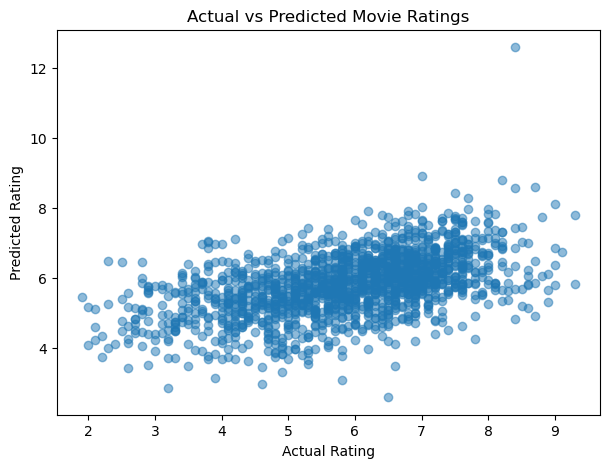

In [60]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()

In [62]:
print("Movie Rating Prediction")
print("----------------------")
print("Model: Ridge Regression")
print("Number of Movies:", len(df))
print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R² Score:", round(r2, 2))

Movie Rating Prediction
----------------------
Model: Ridge Regression
Number of Movies: 7919
Mean Absolute Error: 0.93
Root Mean Squared Error: 1.19
R² Score: 0.23


In [ ]:
# Conclusion
A Ridge Regression model was developed to predict movie ratings using historical movie data.
The dataset was cleaned by handling missing values, and features such as year, duration, votes, genre, director, and actors were used for prediction.
Categorical features were converted into numerical features using One-Hot Encoding. The data was divided into training and testing sets, and the model was evaluated using Mean Absolute Error, Root Mean Squared Error, and R² Score.
This project demonstrates data preprocessing, feature engineering, regression modeling, and model evaluation for movie rating prediction.